In [1]:
import jax
import jax.numpy as jnp
from jax import lax, jit
import matplotlib.pyplot as plt

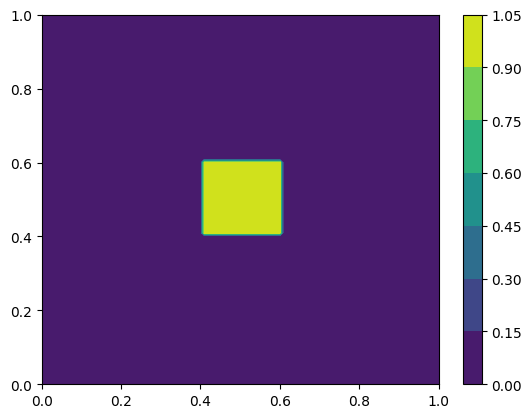

In [149]:
Nx = 101
Ny = 101
L = 1.0
x = jnp.linspace(0.0, L, Nx)
y = x
dx = L / (Nx-1)
dy = dx
u = jnp.zeros((Ny, Nx))

X, Y = jnp.meshgrid(x, y)
# !!! Note: We use the X, Y from meshgrid in order to get a 2D result for b. Otherwise the result would have been a 1D array
b = jnp.where(
    (X>0.4) & (X<0.6) & (Y>0.4) & (Y<0.6),
    1.0,
    0.0
)
b.shape

plt.contourf(x, y, b)
plt.colorbar()
plt.show()

In [150]:
@jit
def Poisson_step(u):
    # Use jnp.roll for central difference stencil (efficient)
    u_plus_1_x = jnp.roll(u, -1, axis=1) # u[i, j+1]
    u_minus_1_x = jnp.roll(u, 1, axis=1) # u[i, j-1]
    u_plus_1_y = jnp.roll(u, -1, axis=0) # u[i+1, j]
    u_minus_1_y = jnp.roll(u, 1, axis=0) # u[i-1, j]
    
    # Jacobi update formula for the INNER grid (1:-1, 1:-1)
    u_next = 0.25 * (
        # u_plus_1_x[1:-1, 1:-1] + u_minus_1_x[1:-1, 1:-1] + 
        # u_plus_1_y[1:-1, 1:-1] + u_minus_1_y[1:-1, 1:-1] +
        # dx**2 * b[1:-1,1:-1]
        + u_plus_1_x + u_minus_1_x + u_plus_1_y + u_minus_1_y
        + dx**2 * b
    )
    
    # Boundary condition set to zero at all boundaries
    # u_next = u.at[1:-1, 1:-1].set(u_next_inner)
    
    return u_next
    

def cond_fn(state):

    _, k = state
    
    return (k < 10000)

def body_fn(state):

    u, k = state
    u_next = Poisson_step(u)
    k_next = k+1

    return u_next, k_next
    


In [151]:
k_init = 0
state = (u, k_init)
u_new, k_final = lax.while_loop(cond_fn, body_fn, state)

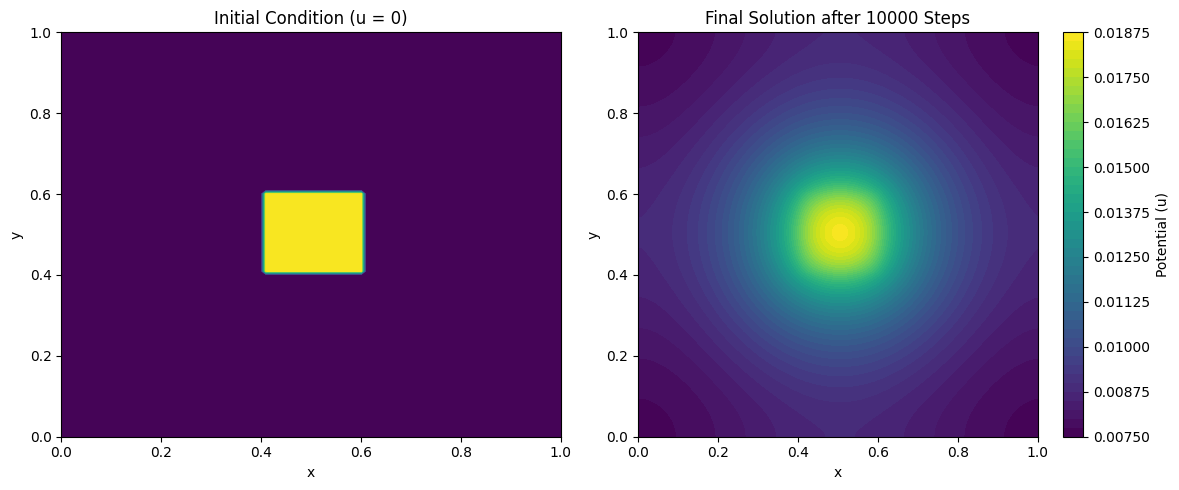

In [152]:
# 1. Create the figure and subplots
# fig: The overall figure container
# axes: A NumPy array containing the individual axes objects (in this case, 1 row, 2 columns)
fig, axes = plt.subplots(
    nrows=1,      # One row of plots
    ncols=2,      # Two columns of plots (Initial and Final)
    figsize=(12, 5) # Increase figure size for side-by-side view
)

# --------------------------
# 2. Plotting on the First Axis (Initial Condition)
# axes[0] refers to the first subplot on the left
ax1 = axes[0] 

# Use the axis object's plotting methods (ax1.contourf instead of plt.contourf)
# Note: Use u_init, which should be the initial zero array
im1 = ax1.contourf(x, y, b, levels=50, cmap='viridis') 

# Set titles and labels on the specific axis object
ax1.set_title('Initial Condition (u = 0)')
ax1.set_xlabel('x')
ax1.set_ylabel('y')

# Add a colorbar for the first plot (optional, since it's just zero)
# fig.colorbar(im1, ax=ax1, label='Potential (u)') 


# --------------------------
# 3. Plotting on the Second Axis (Final Solution)
# axes[1] refers to the second subplot on the right
ax2 = axes[1] 

# Use the axis object's plotting methods (ax2.contourf)
im2 = ax2.contourf(x, y, u_new, levels=50, cmap='viridis')

# Set titles and labels
ax2.set_title(f'Final Solution after {k_final} Steps')
ax2.set_xlabel('x')
ax2.set_ylabel('y')


# --------------------------
# 4. Add a single colorbar for the figure (or one for each plot)
# Creating a colorbar based on the final solution (im2) and positioning it next to ax2
fig.colorbar(im2, ax=ax2, label='Potential (u)')

# 5. Adjust layout to prevent titles/labels from overlapping
plt.tight_layout()

plt.show()


## Solving Poisson equation with a Spectral Method


In [180]:
N = Nx-1
h = N / L

Equation: $\mathcal{F} (\nabla^2 u) = \mathcal{F}(b)$ \
The derivative property of Fourier Transform: $\mathcal{F}(df/dx) = (1j)\frac{2\pi}{L}\hat{f}$ \
PDE in Fourier Domain: $\hat{u} = \frac{\hat{b}}{(\frac{2\pi}{L}^2)}$

## Details about function Implementation
The correct way to apply fft2 is to first compute the fourier of the first integral fully with even the imaginary parts 
hence the k1. Then the k2 is computed based on the more efficient rfft for real function like in fluids. However, after that we need 
to perform kappa = k1^2 + k2^2 which leads to a mismatch. Hence we use meshgrid for that. In that way the operation is performed successfully
and the division b / kappa can be done also successfully. !!! Note that the rfft2(b) --> shape[N, (N/2)+1] like the kappa. The denominator 
is fixed to allow the division. It is changed naturally through algortihm.

In [175]:
@jit
def Spectral_Poisson(u, b):

    k1 = jnp.fft.fftfreq(N, L/(N * 2.0*jnp.pi)) 
    k2 = jnp.fft.rfftfreq(N, L/(N * 2.0*jnp.pi))
    K1, K2 = jnp.meshgrid(k2, k1)
    
    kappa = K1**2 + K2**2
    kappa = kappa.at[0,0].set(1.0)

    b_hat = jnp.fft.rfft2(b)
    b_hat = b_hat.at[0,0].set(0.0)

    uhat_next = b_hat / kappa
    u_next = jnp.fft.irfft2(uhat_next)

    return u_next

In [176]:
mesh_x = jnp.linspace(0.0, L, N, endpoint=False)
mesh_y = jnp.linspace(0.0, L, N, endpoint=False)

X_s, Y_s = jnp.meshgrid(mesh_x, mesh_y)
b_spectal = jnp.where(
    (X_s>0.4) & (X_s<0.6) & (Y_s>0.4) & (Y_s<0.6),
    1.0,
    0.0
)


In [177]:
u0_spectral = jnp.zeros((N, N)) 

In [178]:
u_spectral = Spectral_Poisson(u0_spectral, b_spectal,)


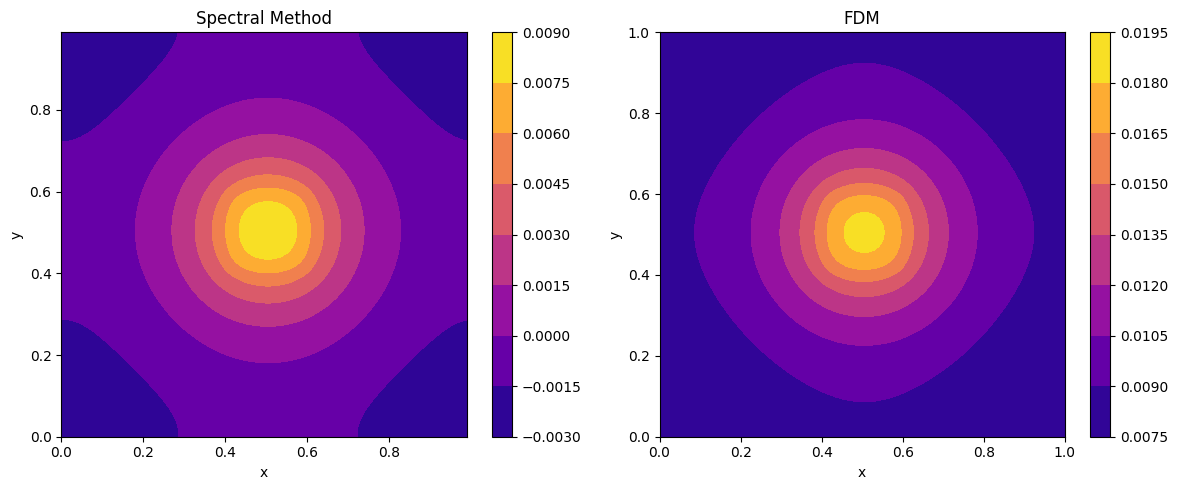

In [179]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12,5))
ax1 = axes[0]
im1 = ax1.contourf(mesh_x, mesh_y, u_spectral,cmap='plasma')
ax1.set_title('Spectral Method')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
fig.colorbar(im1, ax=ax1,)

ax2 = axes[1]
im2 = ax2.contourf(x, y, u_new, cmap='plasma')
ax2.set_title('FDM')
ax2.set_xlabel('x')
ax2.set_ylabel('y')
fig.colorbar(im2, ax=ax2,)
plt.tight_layout()
plt.show()

## Spectral Diffusion 2D
The PDE in Fourier domain is expressed as:\
$ \frac{d\hat{\mathbf{u}}}{dt} = \mathbf{k} \odot \mathbf{\hat{u}} $ \
where $\odot$ symbol is the Hadamard product which in Mathematics/Machine Learning stands for Element-wise product of matrices or vectors.

In [45]:
N = 100
L = 1.0
iterations = 100
dt = 0.001

mesh_x = jnp.linspace(0.0, L, N, endpoint=False)
mesh_y = jnp.linspace(0.0, L, N, endpoint=False)

X_s, Y_s = jnp.meshgrid(mesh_x, mesh_y)
u0 = jnp.where(
    (X_s>0.4) & (X_s<0.6) & (Y_s>0.4) & (Y_s<0.6),
    1.0,
    0.0
)


# Crank-Nickolson

With Central Differences: $u^{n+\frac{1}{2}} = \frac{u^{n+1} - u^{n}}{\Delta t} \ $ 
Therefore finally we get: 

$\hat{u}^{n+1} = \mathbf{\alpha} \odot \hat{u}^n$
where $\mathcal \alpha$ is: $\alpha = \frac{1+0.5\mathbf{k}dt}{1-0.5\mathbf{k}dt}$

In [46]:
@jit
def Cranck_step(u):
    k1 = jnp.fft.fftfreq(N , L/(N*2.0*jnp.pi))
    k2 = jnp.fft.rfftfreq(N, L/(N*2.0*jnp.pi))
    K1, K2 = jnp.meshgrid(k2, k1)
    kappa = -(K1**2 + K2**2)

    factor = jnp.where(
        kappa == 2.0/dt,
        (1.0+0.5*dt)/(1.0-0.5*dt),
        (1.0+0.5*kappa*dt)/(1.0-0.5*kappa*dt)
    )
    
    uhat = jnp.fft.rfft2(u)
    uhat_next = factor * uhat
    u_next = jnp.fft.irfft2(uhat_next)

    return u_next
    

In [47]:
u = u0
for i in range(iterations):
    u = Cranck_step(u)


## Results
The oscillations in the results are due to the Gibbs phenomeno which is caused when the FFT tries to approximate the initial discontinuous conditions. The oscillating phenomena persists even after the dffusion and contaminates computationally a part of the solution.

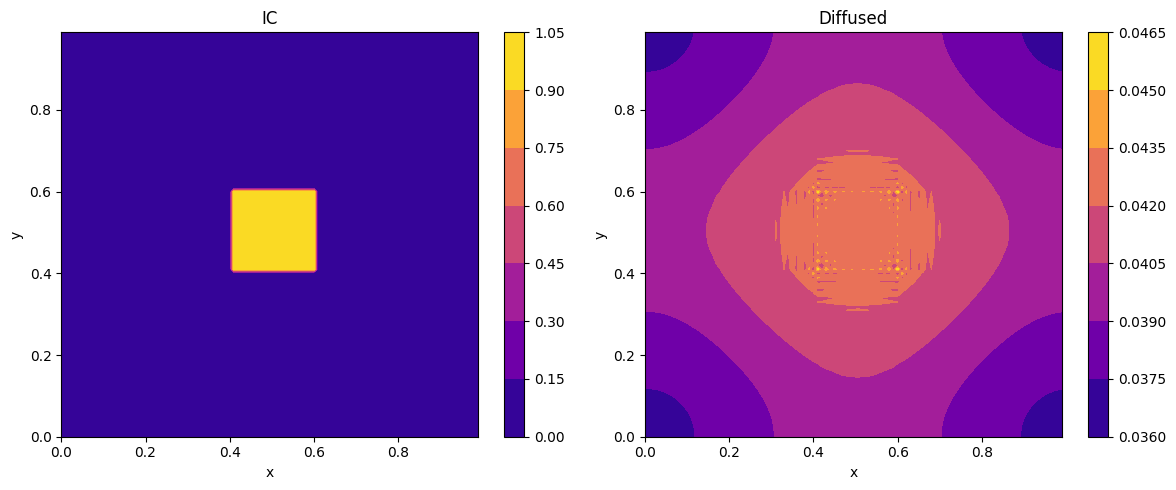

In [48]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12,5))
ax1 = axes[0]
im1 = ax1.contourf(mesh_x, mesh_y, u0,cmap='plasma')
ax1.set_title('IC')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
fig.colorbar(im1, ax=ax1,)

ax2 = axes[1]
im2 = ax2.contourf(mesh_x, mesh_y, u, cmap='plasma')
ax2.set_title('Diffused')
ax2.set_xlabel('x')
ax2.set_ylabel('y')
fig.colorbar(im2, ax=ax2,)
plt.tight_layout()
plt.show()